# Dataset Characterization: Medical Imaging Metadata
This section analyzes the distribution of conditions and potential subgroups (Image Quality and Hospital Site) to identify constraints for model selection and evaluation.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('/content/medical_imaging_meta.csv')

print("Dataset Info:")
display(df.info())
display(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   image_id        520 non-null    object
 1   patient_age     520 non-null    int64 
 2   patient_sex     520 non-null    object
 3   scanner         520 non-null    object
 4   image_quality   520 non-null    object
 5   img_width_px    520 non-null    int64 
 6   hospital_site   520 non-null    object
 7   label           490 non-null    object
 8   label_verified  520 non-null    int64 
dtypes: int64(3), object(6)
memory usage: 36.7+ KB


None

,image_id,patient_age,patient_sex,scanner,image_quality,img_width_px,hospital_site,label,label_verified
0,IMG00000,32,F,Siemens-A1,acceptable,512,Apollo-Hyderabad,Normal,0
1,IMG00001,41,F,Siemens-A1,acceptable,256,Apollo-Hyderabad,Normal,1
2,IMG00002,72,M,Philips-B2,good,512,Manipal-Bangalore,Normal,1
3,IMG00003,50,F,Siemens-A1,good,1024,Manipal-Bangalore,Pneumonia,1
4,IMG00004,63,F,Siemens-A1,acceptable,1024,AIIMS-Delhi,COVID-19,1


## 1. Label Distribution
We examine the frequency of the five conditions to identify class imbalances.

Label Distribution:
label
Normal              311
Pneumonia           112
COVID-19             37
Pleural_Effusion     19
Lung_Mass            11
Name: count, dtype: int64


/tmp/ipykernel_1038/1833011296.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


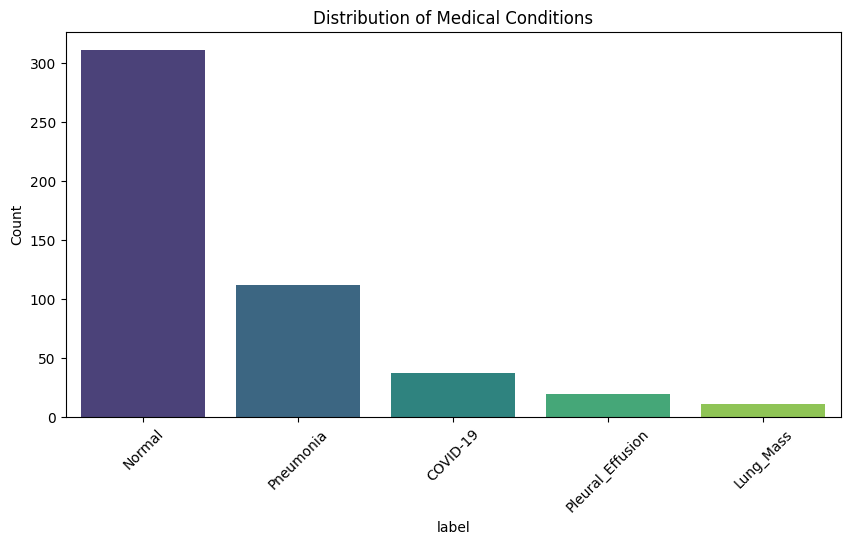

The class with the fewest examples is: Lung_Mass (11 cases)


In [3]:
label_counts = df['label'].value_counts().sort_values(ascending=False)
print("Label Distribution:")
print(label_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Medical Conditions')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

fewest_class = label_counts.idxmin()
print(f"The class with the fewest examples is: {fewest_class} ({label_counts.min()} cases)")

## 2. Subgroup Analysis: Fairness and Quality
We check if certain conditions are over-represented in specific hospital sites or correlate with lower image quality.

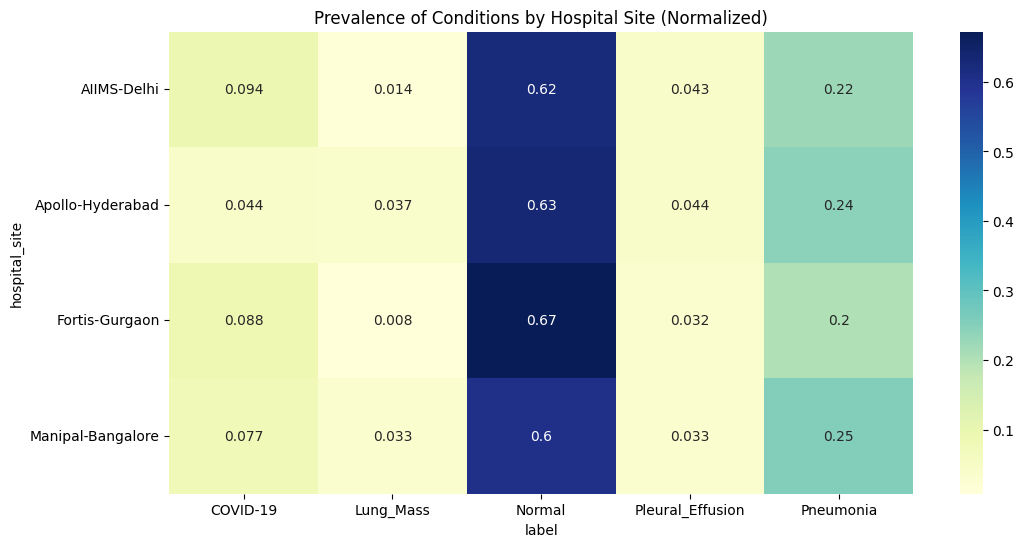

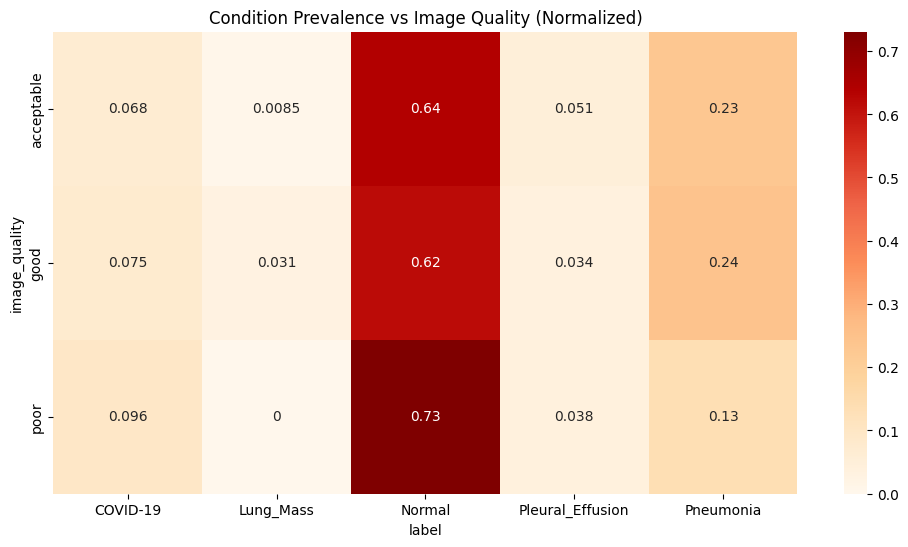

In [6]:
plt.figure(figsize=(12, 6))
site_condition = pd.crosstab(df['hospital_site'], df['label'], normalize='index')
sns.heatmap(site_condition, annot=True, cmap='YlGnBu')
plt.title('Prevalence of Conditions by Hospital Site (Normalized)')
plt.show()

plt.figure(figsize=(12, 6))
quality_condition = pd.crosstab(df['image_quality'], df['label'], normalize='index')
sns.heatmap(quality_condition, annot=True, cmap='OrRd')
plt.title('Condition Prevalence vs Image Quality (Normalized)')
plt.show()